In [1]:
from IPython.display import display
import pandas as pd
def describe_dataset(df: pd.DataFrame):
    display(df.describe())
    display(df['target'].value_counts())


In [2]:
# Standardize Dataset
import pandas as pd
import numpy as np
from config import RANDOM_STATE_SEED
from preprocessing import standardize

def standardize_and_plot_pca(df: pd.DataFrame) -> pd.DataFrame:

    df = standardize(df)
    # Set our RNG seed for reproducibility.
    np.random.seed(RANDOM_STATE_SEED)
    X_raw: pd.DataFrame = df.loc[:, df.columns != 'target']#.to_numpy()
    y_raw: pd.DataFrame = df['target']#.to_numpy()
    # PCA decomposition
    from sklearn.decomposition import PCA

    # Define our PCA transformer and fit it onto our raw dataset.
    pca = PCA(n_components=2, random_state=RANDOM_STATE_SEED)
    transformed_df = pca.fit_transform(X=X_raw)
    %matplotlib inline
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    # Isolate the data we'll need for plotting.
    x_component, y_component = transformed_df[:, 0], transformed_df[:, 1]

    # Plot our dimensionality-reduced (via PCA) dataset.
    plt.figure(figsize=(8.5, 6), dpi=130)
    plt.scatter(x=x_component, y=y_component, c=y_raw, cmap='viridis', s=50, alpha=8/10)
    plt.title('Df classes after PCA transformation')
    plt.show()

    return df

In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from models import SGDLogClassifier, SGDModifiedHuberClassifier
from sklearn.model_selection import train_test_split
from metrics import method_eval

def partial_test_dataset(df: pd.DataFrame):
    dataset_percentages = [10, 30, 50, 70, 90]
    models = [GaussianNB(), KNeighborsClassifier(), SGDLogClassifier(random_state=RANDOM_STATE_SEED), SGDModifiedHuberClassifier(random_state=RANDOM_STATE_SEED)]

    X = df.loc[:, df.columns != 'target']
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

    for model in models:
        print(f"{model.__class__.__name__}\n")
        for p in dataset_percentages:
            size = len(X_train)
            part_of_dataset = int(p/100*size)
            # Randomly sample percentage of dataset
            X = X_train.sample(n=part_of_dataset, random_state=RANDOM_STATE_SEED)
            y = y_train.loc[X.index]
            # Train model on this part
            model.fit(X, y)
            # Evaluate the model
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)
            # Compare model's results
            print(f"Results for {p}%: \n")
            method_eval(y_test, y_pred, y_proba, verbose=1, curves=False)
            print("\n")

Dataset ecoli: 



,0,1,2,3,4,5,6,target
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,0.500060,0.500000,0.495476,0.501488,0.500030,0.500179,0.499732,-0.791667
std,0.194634,0.148157,0.088495,0.027277,0.122376,0.215751,0.209411,0.611864
min,0.000000,0.160000,0.480000,0.500000,0.000000,0.030000,0.000000,-1.000000
25%,0.340000,0.400000,0.480000,0.500000,0.420000,0.330000,0.350000,-1.000000
50%,0.500000,0.470000,0.480000,0.500000,0.495000,0.455000,0.430000,-1.000000
75%,0.662500,0.570000,0.480000,0.500000,0.570000,0.710000,0.710000,-1.000000
max,0.890000,1.000000,1.000000,1.000000,0.880000,1.000000,0.990000,1.000000


-1    301
 1     35
Name: target, dtype: int64

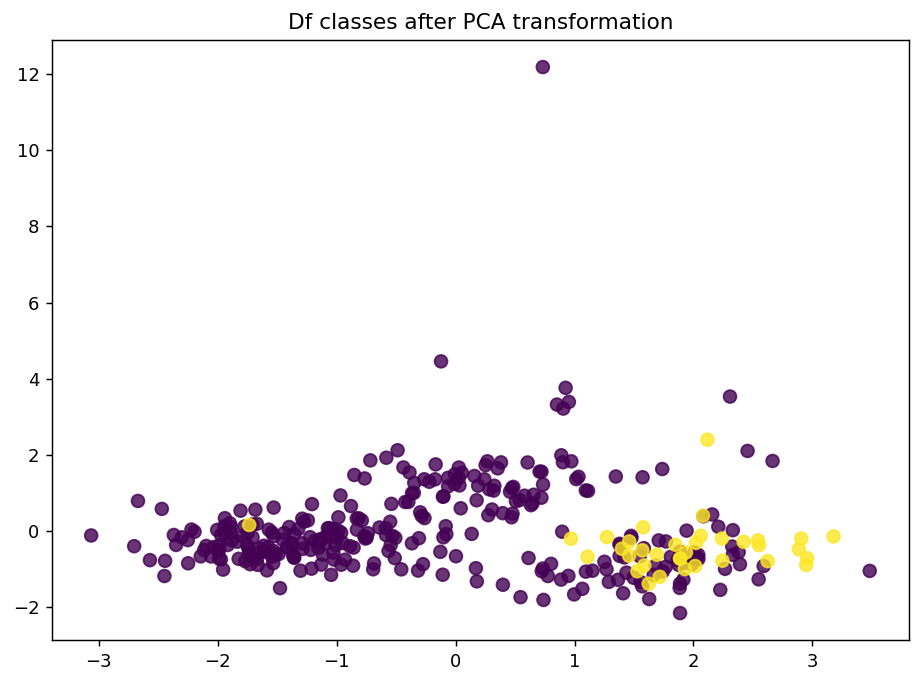

GaussianNB

Results for 10%: 

accuracy: 0.8970588235294118,
precision: 0.0,
recall: 0.0,
f2_score: 0,
auc_pr_curve: 0.5514705882352942,
auc_roc_curve: 0.5


Results for 30%: 

accuracy: 0.7058823529411765,
precision: 0.25925925925925924,
recall: 1.0,
f2_score: 0.6363636363636364,
auc_pr_curve: 0.7232993197278912,
auc_roc_curve: 0.9672131147540983


Results for 50%: 

accuracy: 0.8823529411764706,
precision: 0.46153846153846156,
recall: 0.8571428571428571,
f2_score: 0.7317073170731707,
auc_pr_curve: 0.49623015873015863,
auc_roc_curve: 0.9484777517564402


Results for 70%: 

accuracy: 0.8676470588235294,
precision: 0.42857142857142855,
recall: 0.8571428571428571,
f2_score: 0.7142857142857143,
auc_pr_curve: 0.5941043083900227,
auc_roc_curve: 0.9601873536299765


Results for 90%: 

accuracy: 0.9117647058823529,
precision: 0.5384615384615384,
recall: 1.0,
f2_score: 0.8536585365853658,
auc_pr_curve: 0.8552875695732838,
auc_roc_curve: 0.9789227166276346


KNeighborsClassifier

Results for 10

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,target
count,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000
mean,38.814320,85.120269,40.605622,83.774199,49.770378,65.573144,51.220251,44.498999,56.868541,33.695961,60.516376,34.826510,55.022289,34.937045,47.287482,28.845342,-0.808042
std,34.257783,16.218571,26.342984,19.163646,34.100515,26.996688,30.576881,29.906104,34.135530,27.251548,37.288086,27.119982,22.335539,33.155463,41.760400,35.778094,0.589151
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,6.000000,76.000000,20.000000,72.000000,18.000000,49.000000,28.000000,23.000000,29.000000,7.000000,23.000000,11.000000,42.000000,5.000000,0.000000,0.000000,-1.000000
50%,32.000000,89.000000,40.000000,91.000000,53.000000,71.000000,53.500000,43.000000,60.000000,33.000000,73.000000,30.000000,53.000000,27.000000,40.000000,9.000000,-1.000000
75%,65.000000,100.000000,58.000000,100.000000,78.000000,86.000000,74.000000,64.000000,89.000000,54.000000,97.000000,55.000000,68.000000,47.000000,100.000000,51.000000,-1.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000


-1    9937
 1    1055
Name: target, dtype: int64

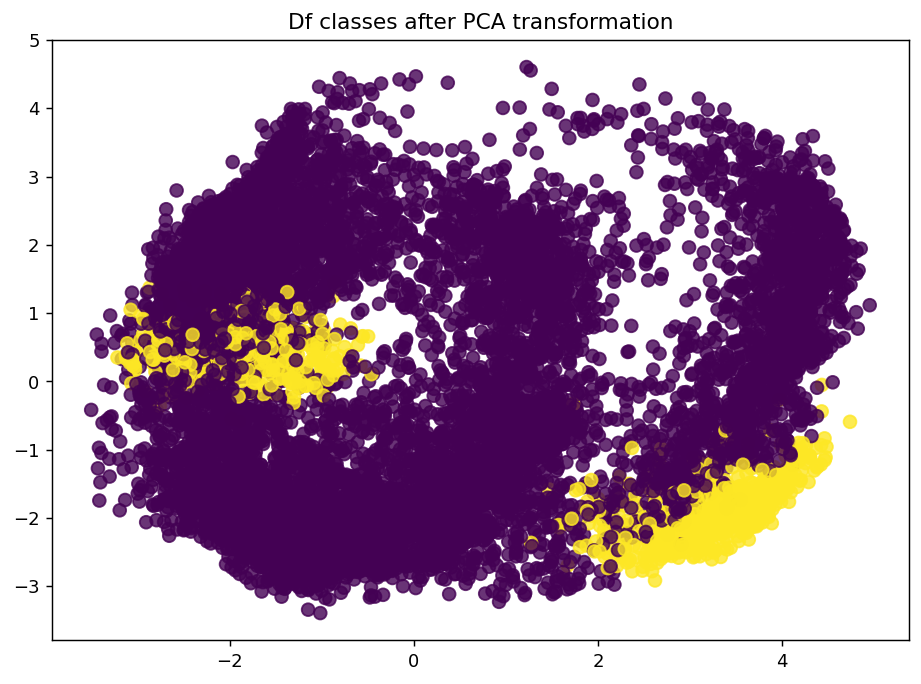

GaussianNB

Results for 10%: 

accuracy: 0.935425193269668,
precision: 0.7116564417177914,
recall: 0.5497630331753555,
f2_score: 0.5759682224428997,
auc_pr_curve: 0.6931642592555659,
auc_roc_curve: 0.9136215396645275


Results for 30%: 

accuracy: 0.9386084583901774,
precision: 0.7289156626506024,
recall: 0.5734597156398105,
f2_score: 0.5990099009900992,
auc_pr_curve: 0.6599409773437229,
auc_roc_curve: 0.8593337274833838


Results for 50%: 

accuracy: 0.9313324238290132,
precision: 0.6685393258426966,
recall: 0.5639810426540285,
f2_score: 0.5821917808219179,
auc_pr_curve: 0.6561059871658064,
auc_roc_curve: 0.8598319776478778


Results for 70%: 

accuracy: 0.9376989540700318,
precision: 0.73125,
recall: 0.5545023696682464,
f2_score: 0.5826693227091634,
auc_pr_curve: 0.6619906225561303,
auc_roc_curve: 0.8709031439823778


Results for 90%: 

accuracy: 0.9386084583901774,
precision: 0.7317073170731707,
recall: 0.5687203791469194,
f2_score: 0.5952380952380951,
auc_pr_curve: 0.66331428787124

,0,1,2,3,4,5,6,7,8,9,target
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.312904,0.321283,0.365813,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,-0.812784
std,0.463731,0.467025,0.481715,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,0.582634
min,0.000000,0.000000,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,-1.000000
25%,0.000000,0.000000,0.000000,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,-1.000000
50%,0.000000,0.000000,0.000000,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,-1.000000
75%,1.000000,1.000000,1.000000,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,-1.000000
max,1.000000,1.000000,1.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,1.000000


-1    3786
 1     391
Name: target, dtype: int64

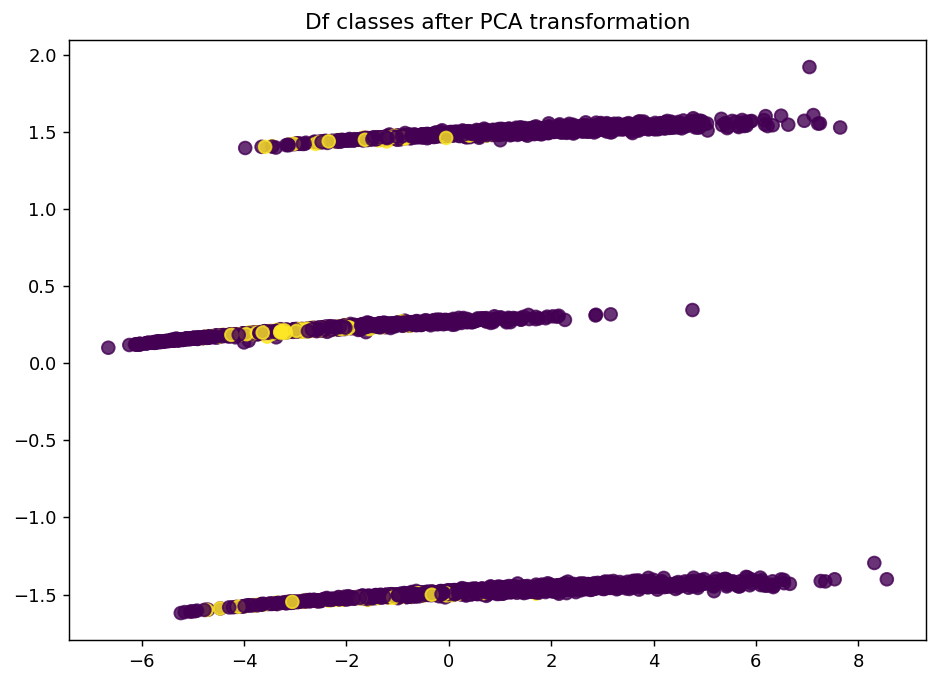

GaussianNB

Results for 10%: 

accuracy: 0.7822966507177034,
precision: 0.26991150442477874,
recall: 0.782051282051282,
f2_score: 0.566914498141264,
auc_pr_curve: 0.3628789547378687,
auc_roc_curve: 0.8510757052973411


Results for 30%: 

accuracy: 0.7440191387559809,
precision: 0.23846153846153847,
recall: 0.7948717948717948,
f2_score: 0.541958041958042,
auc_pr_curve: 0.3822322482486233,
auc_roc_curve: 0.8508389148230837


Results for 50%: 

accuracy: 0.7559808612440191,
precision: 0.248,
recall: 0.7948717948717948,
f2_score: 0.5516014234875445,
auc_pr_curve: 0.3955192899700509,
auc_roc_curve: 0.8461538461538461


Results for 70%: 

accuracy: 0.742822966507177,
precision: 0.23954372623574144,
recall: 0.8076923076923077,
f2_score: 0.5478260869565217,
auc_pr_curve: 0.38543082567478804,
auc_roc_curve: 0.8491306406873689


Results for 90%: 

accuracy: 0.7380382775119617,
precision: 0.23595505617977527,
recall: 0.8076923076923077,
f2_score: 0.5440414507772021,
auc_pr_curve: 0.38035038558574

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,target
count,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,...,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000,3163.000000
mean,50.559911,0.689851,0.287069,0.854252,0.145748,0.982611,0.017389,0.986721,0.013279,0.967120,...,111.486184,0.078407,0.921593,0.986105,0.078090,0.921910,119.808599,0.917800,0.082200,-0.814733
std,20.589843,0.462627,0.452466,0.352909,0.352909,0.130735,0.130735,0.114483,0.114483,0.178351,...,51.575342,0.268853,0.268853,0.261087,0.268356,0.268356,75.032080,0.274713,0.274713,0.579928
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,34.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,83.000000,0.000000,1.000000,0.850000,0.000000,1.000000,90.000000,1.000000,0.000000,-1.000000
50%,53.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,104.000000,0.000000,1.000000,0.960000,0.000000,1.000000,108.000000,1.000000,0.000000,-1.000000
75%,67.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,130.000000,0.000000,1.000000,1.080000,0.000000,1.000000,132.000000,1.000000,0.000000,-1.000000
max,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,450.000000,1.000000,1.000000,2.210000,1.000000,1.000000,881.000000,1.000000,1.000000,1.000000


-1    2870
 1     293
Name: target, dtype: int64

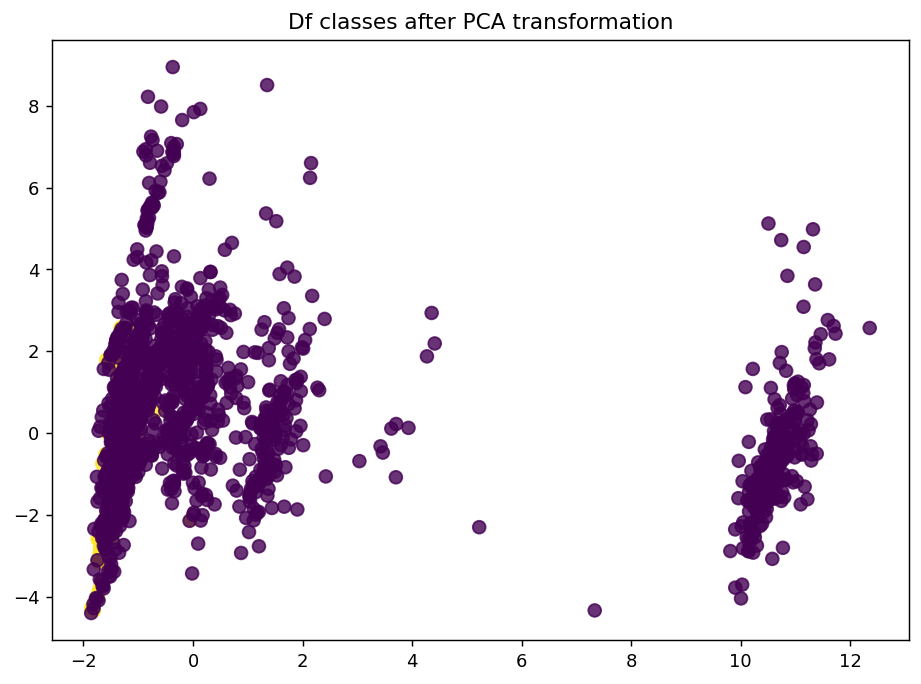

GaussianNB

Results for 10%: 

accuracy: 0.5102685624012638,
precision: 0.14647887323943662,
recall: 0.8813559322033898,
f2_score: 0.43993231810490696,
auc_pr_curve: 0.5194600771033522,
auc_roc_curve: 0.6767259198015709


Results for 30%: 

accuracy: 0.44075829383886256,
precision: 0.1375921375921376,
recall: 0.9491525423728814,
f2_score: 0.43545878693623635,
auc_pr_curve: 0.5458520207214577,
auc_roc_curve: 0.6693881769326169


Results for 50%: 

accuracy: 0.358609794628752,
precision: 0.12526997840172785,
recall: 0.9830508474576272,
f2_score: 0.41487839771101576,
auc_pr_curve: 0.5556066895956345,
auc_roc_curve: 0.6429161991377783


Results for 70%: 

accuracy: 0.36808846761453395,
precision: 0.12691466083150985,
recall: 0.9830508474576272,
f2_score: 0.4184704184704185,
auc_pr_curve: 0.5398624221529265,
auc_roc_curve: 0.6370991554951869


Results for 90%: 

accuracy: 0.36808846761453395,
precision: 0.12362030905077263,
recall: 0.9491525423728814,
f2_score: 0.4063860667634253,
auc_pr_cu

,0,1,2,3,4,5,6,7,8,9,...,84,85,86,87,88,89,90,91,92,target
count,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,...,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000
mean,12541.209977,12237.597084,11964.908625,11537.682054,11101.733085,10819.116949,10424.391799,10280.070452,10106.088973,9997.747461,...,1470.316049,1373.166665,1337.208231,1351.122308,1322.631461,1272.709845,1253.114792,1194.701758,1073.420104,-0.830508
std,5503.167939,5031.317252,4585.085725,4052.584520,3538.717489,3050.139611,2609.524039,2306.188850,2152.268537,2173.905628,...,1180.199059,1130.613602,1143.967066,1180.336500,1178.018265,1157.282074,1170.577250,1123.733151,968.482164,0.557531
min,-460.896450,287.154570,1654.362800,599.764200,1561.761600,1680.023400,1865.629800,1476.868800,1215.385900,565.382930,...,194.543260,182.580570,216.444440,-15.282752,114.827950,264.006200,164.322250,-17.147625,110.874400,-1.000000
25%,8074.148750,8001.957200,8148.328250,8201.155500,8484.753500,8746.968000,8956.825000,9232.578500,9327.731000,9234.500500,...,892.985520,817.332930,776.278075,783.377935,760.454915,714.886730,699.183750,662.240450,597.853715,-1.000000
50%,11878.322000,11915.940000,11723.886000,11292.897000,10760.883000,10529.428000,10292.296000,10278.835000,10391.324000,10375.595000,...,1201.621300,1106.895400,1058.174400,1094.039200,1045.647600,988.230500,973.379400,921.598750,839.561100,-1.000000
75%,15377.557500,15163.935000,15018.602000,14348.957500,13594.444500,12858.561500,12076.403000,11664.955000,11303.750500,11300.875500,...,1554.170750,1462.659200,1408.338200,1376.312700,1357.530650,1338.485050,1297.319450,1232.466100,1122.141550,-1.000000
max,34736.387000,36548.805000,34748.820000,29966.598000,23261.822000,18706.330000,18211.516000,17742.465000,16431.188000,15360.049000,...,8648.441000,8189.396500,8672.912000,8748.417000,9028.503000,8661.756000,8855.052000,8426.325000,7169.083000,1.000000


-1    486
 1     45
Name: target, dtype: int64

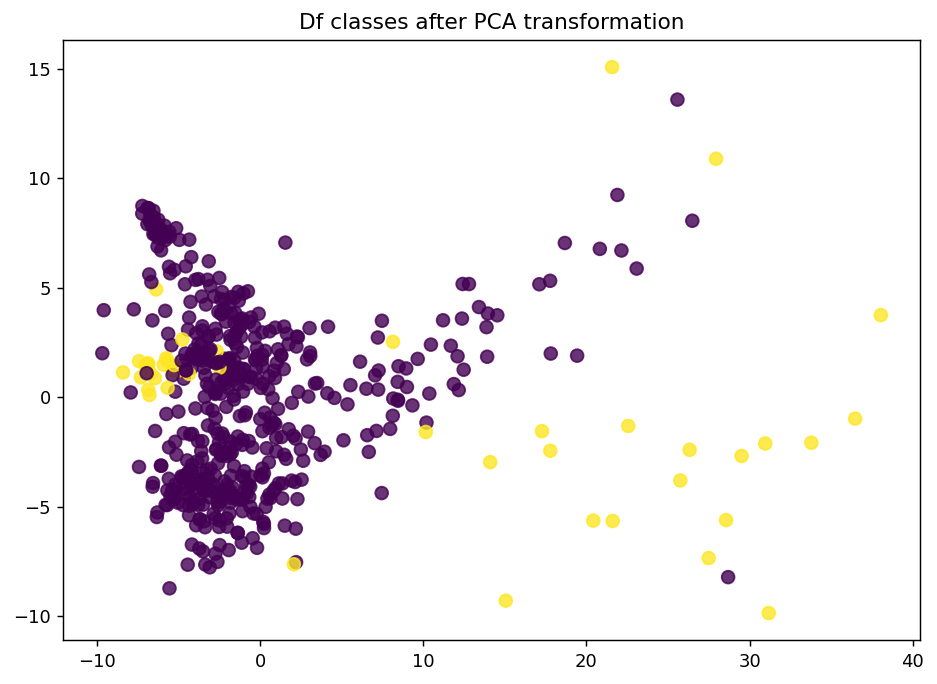

GaussianNB

Results for 10%: 

accuracy: 0.8691588785046729,
precision: 0.2222222222222222,
recall: 0.2222222222222222,
f2_score: 0.2222222222222222,
auc_pr_curve: 0.2402327902576,
auc_roc_curve: 0.6791383219954649


Results for 30%: 

accuracy: 0.8785046728971962,
precision: 0.25,
recall: 0.2222222222222222,
f2_score: 0.22727272727272727,
auc_pr_curve: 0.23462758529837086,
auc_roc_curve: 0.6859410430839002


Results for 50%: 

accuracy: 0.8785046728971962,
precision: 0.25,
recall: 0.2222222222222222,
f2_score: 0.22727272727272727,
auc_pr_curve: 0.24229238112363155,
auc_roc_curve: 0.7142857142857142


Results for 70%: 

accuracy: 0.8785046728971962,
precision: 0.25,
recall: 0.2222222222222222,
f2_score: 0.22727272727272727,
auc_pr_curve: 0.2562300221990923,
auc_roc_curve: 0.743764172335601


Results for 90%: 

accuracy: 0.8785046728971962,
precision: 0.25,
recall: 0.2222222222222222,
f2_score: 0.22727272727272727,
auc_pr_curve: 0.24465850373270615,
auc_roc_curve: 0.7210884353741497


K

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,target
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,...,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,-0.844907
std,0.433138,0.433138,0.433138,0.433138,0.433138,0.433138,0.433138,0.433138,0.433138,0.433138,...,0.471541,0.471541,0.471541,0.471541,0.471541,0.471541,0.471541,0.471541,0.471541,0.535067
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
75%,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


-1    1594
 1     134
Name: target, dtype: int64

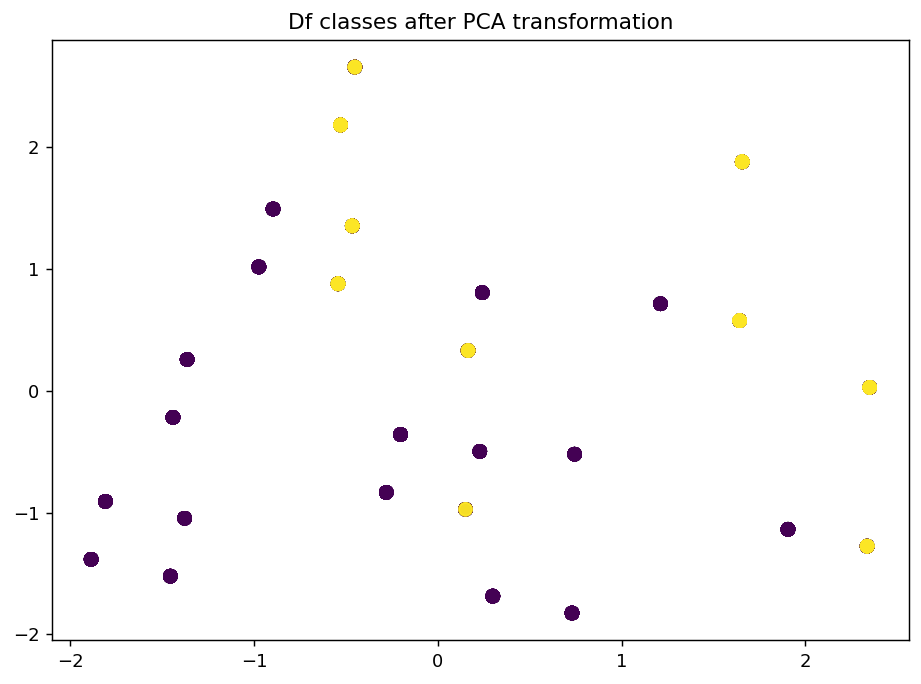

GaussianNB

Results for 10%: 

accuracy: 0.9219653179190751,
precision: 0.5,
recall: 1.0,
f2_score: 0.8333333333333334,
auc_pr_curve: 0.75,
auc_roc_curve: 0.957680250783699


Results for 30%: 

accuracy: 0.9219653179190751,
precision: 0.5,
recall: 1.0,
f2_score: 0.8333333333333334,
auc_pr_curve: 0.75,
auc_roc_curve: 0.957680250783699


Results for 50%: 

accuracy: 0.9219653179190751,
precision: 0.5,
recall: 1.0,
f2_score: 0.8333333333333334,
auc_pr_curve: 0.75,
auc_roc_curve: 0.957680250783699


Results for 70%: 

accuracy: 0.9219653179190751,
precision: 0.5,
recall: 1.0,
f2_score: 0.8333333333333334,
auc_pr_curve: 0.75,
auc_roc_curve: 0.957680250783699


Results for 90%: 

accuracy: 0.9219653179190751,
precision: 0.5,
recall: 1.0,
f2_score: 0.8333333333333334,
auc_pr_curve: 0.75,
auc_roc_curve: 0.957680250783699


KNeighborsClassifier

Results for 10%: 

accuracy: 0.9277456647398844,
precision: 0.5714285714285714,
recall: 0.2962962962962963,
f2_score: 0.32786885245901637,
auc_pr_curve

In [4]:
# Benchmark Datasets
from benchmark import Benchmark

datasets = Benchmark.load_all_benchmark_datasets()
datasets_names = ["ecoli", "pen_digits", "abalone", "sick_euthyroid", "spectrometer", "car_eval_34"]

for dataset_name in datasets_names:
    print(f"Dataset {dataset_name}: \n")
    df = datasets[dataset_name]
    describe_dataset(df)
    df = standardize_and_plot_pca(df)
    partial_test_dataset(df)
